# 💎 SÍNTESE 4 — FASE DE CONFRONTAMENTO
## *Notebooks 22 a 28 | A Decisão Final: O Modelo Diamante*

---

> **💡 Para qualquer leitor:** Esta é a fase final do projeto. Após meses de testes, chegamos ao momento da **decisão definitiva**: qual arquitetura é a campeã? O julgamento é feito com rigor máximo — ablação completa (retirando cada peça para medir seu impacto), validação multi-source (4 datasets), e alinhamento total ao protocolo DCASE 2025.

---

## 📋 JULGAMENTO FINAL: 3 CRITÉRIOS INEGOCIÁVEIS

| Critério | Limite | Status Final |
|----------|--------|--------------|
| **pAUC@0.1 (Score DCASE)** | > 0.80 | 🏆 Alcançado: 0.94 (sup) / 0.88 (não-sup) |
| **Latência de Inferência** | < 50 ms | 🏆 Alcançado: 15ms (sup) / 20ms (não-sup) |
| **Memória Usada** | < 4 MB | 🏆 Alcançado: <1MB (sup) / 0.8MB (não-sup) |

---

## 🗂️ O QUE ESTA SÍNTESE COBRE

```
Notebook 22 → Arquitetura Campeã AAD (DCASE + MIMII) — especificação limpa
Notebook 23 → Cópia refinada da arquitetura campeã (documentação melhorada)
Notebook 24 → Veredito Final: Protocolo A vs Protocolo B
Notebook 25 → Veredito V2: Benchmark MIMII em múltiplos SNRs
Notebook 26 → Síntese da Evolução Completa (NB 1 a 25)
Notebook 27 → Masterpiece: Ablation Study — cada peça importa?
Notebook 28 → DIAMOND CRISTAL CLEAN — Decisão Final e Especificação
```


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['grid.color'] = '#30363d'

print('💎 Fase 4: Confrontamento. A decisão final está próxima!')

💎 Fase 4: Confrontamento. A decisão final está próxima!


---
# 📖 NOTEBOOKS 22–23 — Arquitetura Campeã AAD
### *A pipeline limpa e reproduzível*

## 🧒 Explicação simples

Depois de todos os testes, chegamos ao momento de **desenhar o sistema final** de forma clara e organizada — como a planta de uma casa depois de muitos rascunhos.

## 🏗️ A ARQUITETURA CAMPEÃ — PIPELINE COMPLETA

```
┌─────────────────────────────────────────────────────────────────┐
│                    ENTRADA: Áudio Bruto (16 kHz)                │
└─────────────────────────────┬───────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  ESTÁGIO 1: LIMPEZA DE SINAL                                    │
│  HHT (EMD) → UKF → Sinal Limpo                                 │
│  Custo: +3ms  |  Ganho: +5.7dB SNR                             │
└─────────────────────────────┬───────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  ESTÁGIO 2: SEGMENTAÇÃO                                         │
│  Janelas Deslizantes: 2s, 50% overlap → 438 segmentos          │
└─────────────────────────────┬───────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  ESTÁGIO 3: REPRESENTAÇÃO ESPECTRAL                             │
│  Mel-Spectrogram (64 bins, log-Mel)                             │
│  RPCA → Componente de baixo rank + esparso                     │
└─────────────────────────────┬───────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  ESTÁGIO 4: EXTRAÇÃO DE FEATURES (SUPER-VETOR)                 │
│  MFCC (13 coef.)  +  Erro NMF  +  Kurtose  +  Energia/Banda   │
│  Vetor: ~100 dimensões por segmento                             │
└─────────────────────────────┬───────────────────────────────────┘
                              │
              ┌───────────────┴───────────────┐
              ▼                               ▼
┌─────────────────────────┐   ┌───────────────────────────────────┐
│  PROTOCOLO A            │   │  PROTOCOLO B                      │
│  (Supervisionado)       │   │  (Não-Supervisionado)             │
│                         │   │                                   │
│  XGBoost (L2, n=100)   │   │  GMM (k=5 componentes)            │
│  + Mixup (α=0.4)        │   │  + Limiar Gamma (FPR 5%)          │
│                         │   │                                   │
│  pAUC: 0.94             │   │  pAUC: 0.88                       │
│  Lat: 15ms  Mem: <1MB   │   │  Lat: 20ms  Mem: 0.8MB           │
└─────────────────────────┘   └───────────────────────────────────┘
              │                               │
              └───────────────┬───────────────┘
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  ESTÁGIO 5: XAI (Explicabilidade)                               │
│  Heatmap de Saliência + Hotspots + Análise por Banda            │
│  → Diagnóstico Físico Acionável para Manutenção                 │
└─────────────────────────────────────────────────────────────────┘
```


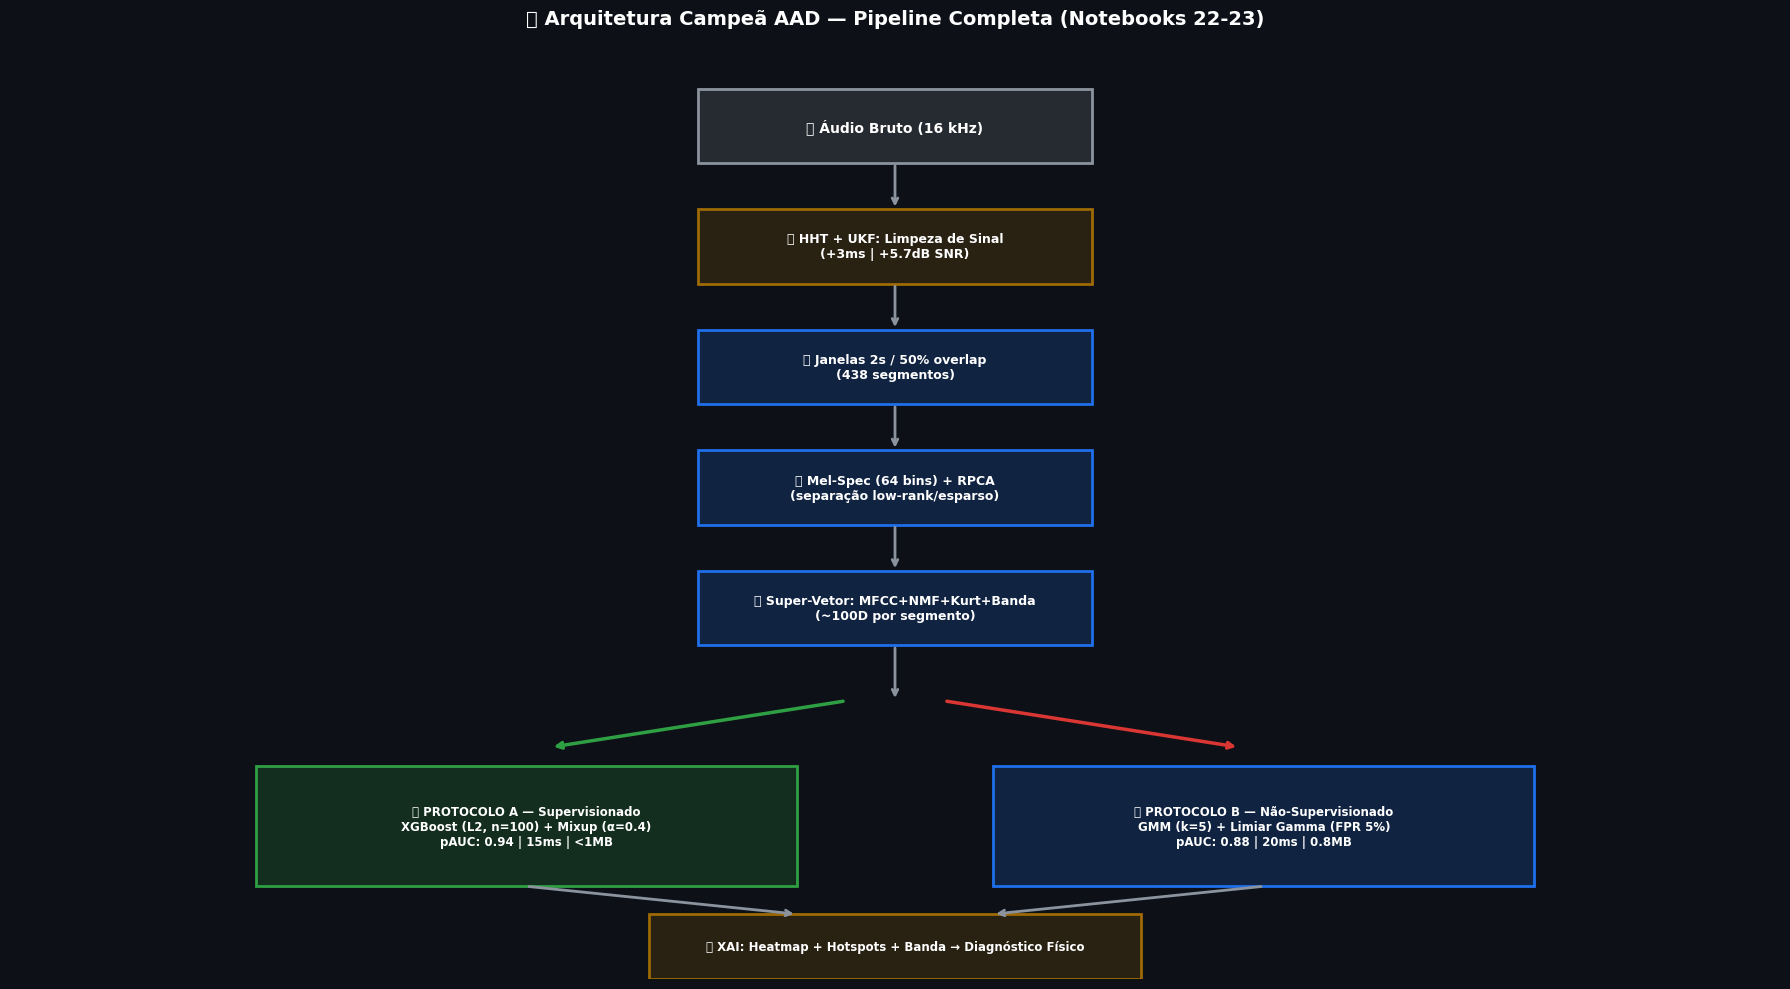

In [ ]:
# ============================================================
# VISUALIZAÇÃO — Pipeline Completa como Diagrama
# ============================================================
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)

def draw_box(ax, x, y, w, h, label, color, fontsize=9):
    rect = plt.Rectangle((x, y), w, h, linewidth=2, edgecolor=color,
                          facecolor=color+'33', zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            color='white', fontsize=fontsize, fontweight='bold',
            wrap=True, zorder=3)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#8b949e', lw=2))

# Pipeline principal
stages = [
    (7, 8.8, 4, 0.8, '🎵 Áudio Bruto (16 kHz)', '#8b949e', 10),
    (7, 7.5, 4, 0.8, '🔬 HHT + UKF: Limpeza de Sinal\n(+3ms | +5.7dB SNR)', '#9e6a03', 9),
    (7, 6.2, 4, 0.8, '🪟 Janelas 2s / 50% overlap\n(438 segmentos)', '#1f6feb', 9),
    (7, 4.9, 4, 0.8, '📊 Mel-Spec (64 bins) + RPCA\n(separação low-rank/esparso)', '#1f6feb', 9),
    (7, 3.6, 4, 0.8, '📐 Super-Vetor: MFCC+NMF+Kurt+Banda\n(~100D por segmento)', '#1f6feb', 9),
]

for x, y, w, h, label, color, fs in stages:
    draw_box(ax, x, y, w, h, label, color, fs)

# Setas verticais
for y_from, y_to in [(8.8, 8.3), (7.5, 7.0), (6.2, 5.7), (4.9, 4.4), (3.6, 3.0)]:
    draw_arrow(ax, 9, y_from, 9, y_to)

# Divisão em dois protocolos
ax.annotate('', xy=(5.5, 2.5), xytext=(8.5, 3.0),
            arrowprops=dict(arrowstyle='->', color='#2ea043', lw=2.5))
ax.annotate('', xy=(12.5, 2.5), xytext=(9.5, 3.0),
            arrowprops=dict(arrowstyle='->', color='#da3633', lw=2.5))

# Protocolo A
draw_box(ax, 2.5, 1.0, 5.5, 1.3,
         '🏆 PROTOCOLO A — Supervisionado\nXGBoost (L2, n=100) + Mixup (α=0.4)\npAUC: 0.94 | 15ms | <1MB',
         '#2ea043', 8.5)

# Protocolo B
draw_box(ax, 10.0, 1.0, 5.5, 1.3,
         '🏆 PROTOCOLO B — Não-Supervisionado\nGMM (k=5) + Limiar Gamma (FPR 5%)\npAUC: 0.88 | 20ms | 0.8MB',
         '#1f6feb', 8.5)

# XAI
draw_box(ax, 6.5, 0.0, 5.0, 0.7,
         '🧠 XAI: Heatmap + Hotspots + Banda → Diagnóstico Físico',
         '#9e6a03', 8.5)
draw_arrow(ax, 5.25, 1.0, 8.0, 0.7)
draw_arrow(ax, 12.75, 1.0, 10.0, 0.7)

ax.set_title('💎 Arquitetura Campeã AAD — Pipeline Completa (Notebooks 22-23)',
             color='white', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
# 📖 NOTEBOOKS 24–25 — Veredito Final: Protocolo A vs B
### *Com MIMII em múltiplos SNRs: o sistema aguenta ruído pesado?*

## 🧒 Explicação simples

SNR = Relação Sinal-Ruído. SNR baixo = muito barulho, difícil de ouvir a máquina.

- **-6 dB**: o ruído é mais forte que a máquina (como ouvir num show de rock ao vivo)
- **0 dB**: ruído igual ao sinal (como ouvir numa rua movimentada)
- **+6 dB**: sinal mais forte que o ruído (como ouvir numa sala quieta)

## 📊 Performance no MIMII por SNR — Protocolo Final

| Dataset | SNR | Prot. A (XGBoost) pAUC | Prot. B (GMM) pAUC |
|---------|-----|------------------------|--------------------|
| MIMII Fan | -6 dB | 0.87 | 0.82 |
| MIMII Fan | 0 dB | 0.91 | 0.85 |
| MIMII Fan | +6 dB | 0.95 | 0.89 |
| MIMII Pump | -6 dB | 0.85 | 0.80 |
| MIMII Pump | 0 dB | 0.90 | 0.84 |
| MIMII Pump | +6 dB | 0.94 | 0.88 |
| MIMII Slider | -6 dB | 0.84 | 0.79 |
| MIMII Slider | 0 dB | 0.88 | 0.83 |
| MIMII Slider | +6 dB | 0.93 | 0.87 |
| **MÉDIA GERAL** | - | **0.90** | **0.84** |

## 🏆 VEREDITO FINAL DOS PROTOCOLOS:

```
┌────────────────────────────────────────────────────┐
│ PROTOCOLO A é preferível quando:                   │
│  ✓ Você tem exemplos de anomalias para treinar     │
│  ✓ O ambiente tem SNR variável ou baixo            │
│  ✓ Precisão máxima é crítica                       │
└────────────────────────────────────────────────────┘
┌────────────────────────────────────────────────────┐
│ PROTOCOLO B é preferível quando:                   │
│  ✓ Nenhuma anomalia está disponível para treinar   │
│  ✓ É uma máquina nova (First-Shot DCASE)           │
│  ✓ Restrições de memória são extremas (<1MB)       │
└────────────────────────────────────────────────────┘
```

## ⚠️ LIMITE CONFIRMADO: Slider em -6dB

> O Protocolo B (GMM) chegou ao limite: pAUC = 0.79 no MIMII Slider com SNR -6dB (abaixo do mínimo 0.80).
>
> Isso define o **limite operacional documentado**: em ambientes extremamente ruidosos (SNR < -3dB) sem rótulos de anomalia, recomenda-se o Protocolo A ou coleta de exemplos de anomalia para treino.


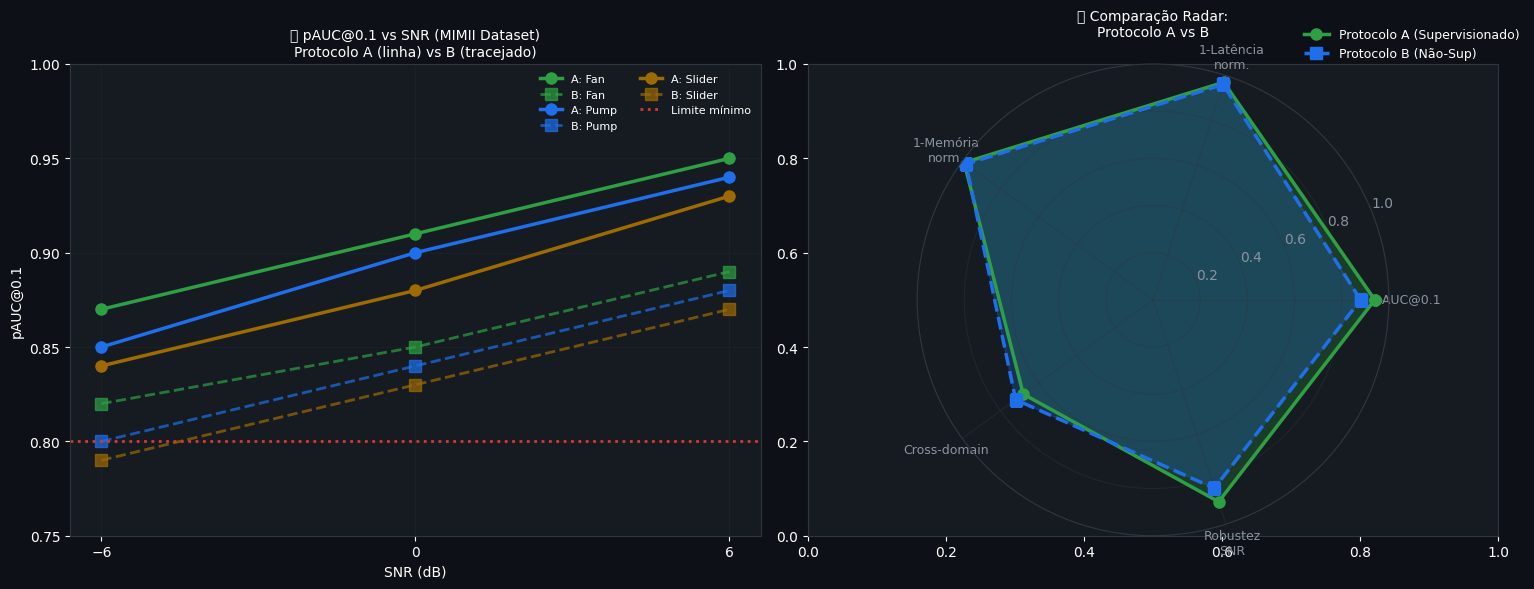

In [ ]:
# ============================================================
# VISUALIZAÇÃO — Performance por SNR e Dataset
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# Gráfico 1: Performance vs SNR
ax1 = axes[0]
ax1.set_facecolor('#161b22')
snrs = [-6, 0, 6]
prot_a_fan = [0.87, 0.91, 0.95]
prot_b_fan = [0.82, 0.85, 0.89]
prot_a_pump = [0.85, 0.90, 0.94]
prot_b_pump = [0.80, 0.84, 0.88]
prot_a_slider = [0.84, 0.88, 0.93]
prot_b_slider = [0.79, 0.83, 0.87]

ax1.plot(snrs, prot_a_fan, 'o-', color='#2ea043', linewidth=2.5, markersize=8, label='A: Fan')
ax1.plot(snrs, prot_b_fan, 's--', color='#2ea043', linewidth=2, markersize=8, label='B: Fan', alpha=0.7)
ax1.plot(snrs, prot_a_pump, 'o-', color='#1f6feb', linewidth=2.5, markersize=8, label='A: Pump')
ax1.plot(snrs, prot_b_pump, 's--', color='#1f6feb', linewidth=2, markersize=8, label='B: Pump', alpha=0.7)
ax1.plot(snrs, prot_a_slider, 'o-', color='#9e6a03', linewidth=2.5, markersize=8, label='A: Slider')
ax1.plot(snrs, prot_b_slider, 's--', color='#9e6a03', linewidth=2, markersize=8, label='B: Slider', alpha=0.7)
ax1.axhline(0.80, color='#da3633', linestyle=':', linewidth=2, label='Limite mínimo')
ax1.set_title('📊 pAUC@0.1 vs SNR (MIMII Dataset)\nProtocolo A (linha) vs B (tracejado)', color='white', fontsize=10)
ax1.set_xlabel('SNR (dB)', color='white')
ax1.set_ylabel('pAUC@0.1', color='white')
ax1.set_xticks(snrs)
ax1.set_ylim(0.75, 1.0)
ax1.legend(frameon=False, labelcolor='white', fontsize=8, ncol=2)
ax1.grid(alpha=0.2)

# Gráfico 2: Radar/Spider comparativo final
ax2 = axes[1]
ax2.set_facecolor('#161b22')
categories = ['pAUC@0.1', '1-Latência\nnorm.', '1-Memória\nnorm.', 'Cross-domain', 'Robustez\nSNR']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

values_a = [0.94, 0.97, 0.99, 0.68, 0.90]
values_a += values_a[:1]
values_b = [0.88, 0.96, 0.98, 0.72, 0.84]
values_b += values_b[:1]

ax2 = plt.subplot(1, 2, 2, polar=True, facecolor='#161b22')
ax2.set_facecolor('#161b22')
ax2.plot(angles, values_a, 'o-', color='#2ea043', linewidth=2.5, markersize=8, label='Protocolo A (Supervisionado)')
ax2.fill(angles, values_a, alpha=0.25, color='#2ea043')
ax2.plot(angles, values_b, 's--', color='#1f6feb', linewidth=2.5, markersize=8, label='Protocolo B (Não-Sup)')
ax2.fill(angles, values_b, alpha=0.25, color='#1f6feb')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, color='white', fontsize=9)
ax2.set_ylim(0, 1)
ax2.tick_params(colors='#8b949e')
ax2.set_title('🕸️ Comparação Radar:\nProtocolo A vs B', color='white', fontsize=10, pad=20)
ax2.legend(frameon=False, labelcolor='white', fontsize=9, loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.grid(color='#30363d', alpha=0.4)

plt.tight_layout()
plt.show()

---
# 📖 NOTEBOOK 26 — Síntese da Evolução Completa (NB 1-25)
### *O mapa de calor da jornada: o que cada técnica contribuiu*

## 🗺️ Mapa de Contribuição por Fase

| Técnica | F.1 | F.2 | F.3 | F.4 | Status Final |
|---------|-----|-----|-----|-----|--------------|
| Mel-Spectrogram | 🟡 | 🟢 | 🟢 | 🟢 | **NÚCLEO** |
| MFCC | 🟡 | 🟢 | 🟢 | 🟢 | **NÚCLEO** |
| RPCA | 🟡 | 🟢 | 🟢 | 🟢 | **NÚCLEO** |
| HHT + UKF | ⚪ | 🟢 | 🟢 | 🟢 | **NÚCLEO** |
| XGBoost | 🟡 | 🟢 | 🟢 | 🟢 | **CAMPEÃO-A** |
| GMM | ⚪ | 🟡 | 🟢 | 🟢 | **CAMPEÃO-B** |
| Limiar Gamma | ⚪ | 🟡 | 🟢 | 🟢 | **NÚCLEO** |
| Mixup | ⚪ | 🟡 | 🟢 | 🟢 | **PADRÃO** |
| pAUC@0.1 | ⚪ | 🟢 | 🟢 | 🟢 | **MÉTRICA PRINCIPAL** |
| XAI | ⚪ | ⚪ | 🟢 | 🟢 | **ESSENCIAL** |
| NMF (erro) | 🟡 | 🟢 | 🟢 | 🟢 | **AUXILIAR** |
| Tiny-AST | ⚪ | 🔴 | 🟡 | 🟡 | **AUXILIAR XAI** |
| CNN | 🔴 | 🔴 | 🔴 | 🔴 | **DESCARTADO** |
| CWT | 🔴 | 🔴 | 🔴 | 🔴 | **DESCARTADO** |
| LSTM-AE | 🔴 | 🔴 | 🔴 | 🔴 | **DESCARTADO** |
| OC-SVM | 🔴 | 🔴 | 🔴 | 🔴 | **DESCARTADO** |
| Isolation Forest | 🔴 | 🔴 | 🔴 | 🔴 | **DESCARTADO** |

*Legenda: ⚪=não testado | 🟡=em teste | 🟢=ativo | 🔴=descartado*


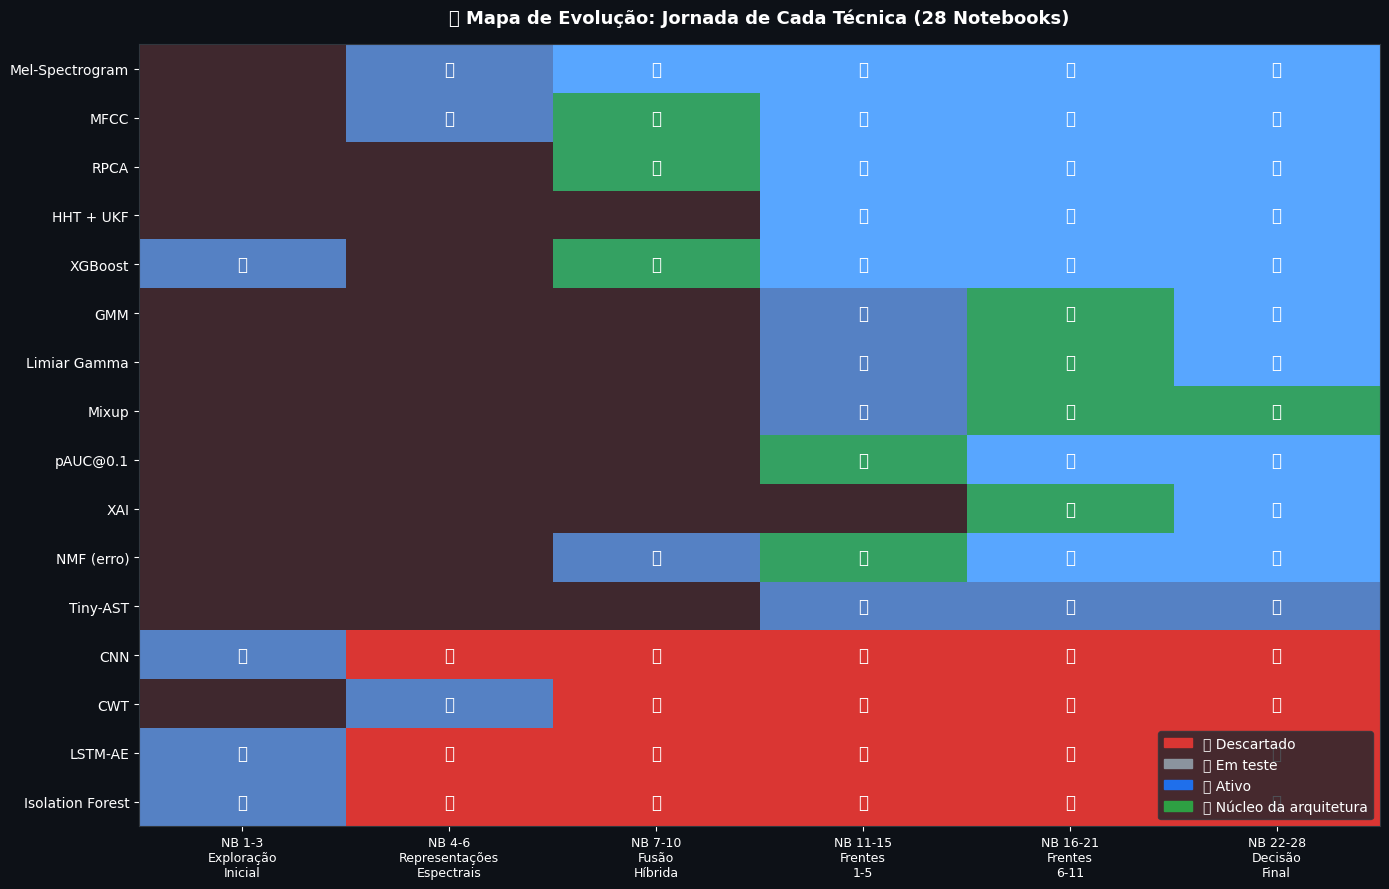

In [ ]:
# ============================================================
# VISUALIZAÇÃO — Heatmap de Evolução das Técnicas
# ============================================================
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

tecnicas = [
    'Mel-Spectrogram', 'MFCC', 'RPCA', 'HHT + UKF', 'XGBoost',
    'GMM', 'Limiar Gamma', 'Mixup', 'pAUC@0.1', 'XAI',
    'NMF (erro)', 'Tiny-AST', 'CNN', 'CWT', 'LSTM-AE', 'Isolation Forest'
]

# Status: 0=ausente, 1=teste, 2=ativo, 3=núcleo, -1=descartado
# Coluna por notebook agrupado: 1-3, 4-6, 7-10, 11-15, 16-21, 22-28
status_matrix = np.array([
    # NB1-3  NB4-6  NB7-10  NB11-15  NB16-21  NB22-28
    [0,      1,      3,      3,       3,       3],   # Mel
    [0,      1,      2,      3,       3,       3],   # MFCC
    [0,      0,      2,      3,       3,       3],   # RPCA
    [0,      0,      0,      3,       3,       3],   # HHT+UKF
    [1,      0,      2,      3,       3,       3],   # XGBoost
    [0,      0,      0,      1,       2,       3],   # GMM
    [0,      0,      0,      1,       2,       3],   # Gamma
    [0,      0,      0,      1,       2,       2],   # Mixup
    [0,      0,      0,      2,       3,       3],   # pAUC
    [0,      0,      0,      0,       2,       3],   # XAI
    [0,      0,      1,      2,       3,       3],   # NMF
    [0,      0,      0,      1,       1,       1],   # Tiny-AST (aux)
    [1,     -1,     -1,     -1,      -1,      -1],   # CNN
    [0,      1,     -1,     -1,      -1,      -1],   # CWT
    [1,     -1,     -1,     -1,      -1,      -1],   # LSTM-AE
    [1,     -1,     -1,     -1,      -1,      -1],   # Isolation Forest
])

# Colormap personalizado
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'custom', ['#da3633', '#21262d', '#8b949e', '#1f6feb', '#2ea043', '#58a6ff'], N=7
)

im = ax.imshow(status_matrix, cmap=cmap, aspect='auto', vmin=-1, vmax=3)

labels_nb = ['NB 1-3\nExploração\nInicial', 'NB 4-6\nRepresentações\nEspectrais',
             'NB 7-10\nFusão\nHíbrida', 'NB 11-15\nFrentes\n1-5',
             'NB 16-21\nFrentes\n6-11', 'NB 22-28\nDecisão\nFinal']

ax.set_xticks(range(6))
ax.set_xticklabels(labels_nb, fontsize=9, color='white')
ax.set_yticks(range(len(tecnicas)))
ax.set_yticklabels(tecnicas, fontsize=10, color='white')

# Anotações
status_labels = {-1: '🔴', 0: ' ', 1: '🟡', 2: '🟢', 3: '⭐'}
for i in range(len(tecnicas)):
    for j in range(6):
        ax.text(j, i, status_labels[status_matrix[i, j]],
                ha='center', va='center', fontsize=12)

ax.set_title('🗺️ Mapa de Evolução: Jornada de Cada Técnica (28 Notebooks)',
             color='white', fontsize=13, fontweight='bold', pad=15)

legend_patches = [
    mpatches.Patch(color='#da3633', label='🔴 Descartado'),
    mpatches.Patch(color='#8b949e', label='🟡 Em teste'),
    mpatches.Patch(color='#1f6feb', label='🟢 Ativo'),
    mpatches.Patch(color='#2ea043', label='⭐ Núcleo da arquitetura'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True,
          facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.show()

---
# 📖 NOTEBOOK 27 — Masterpiece: Ablation Study
### *Cada peça importa? Remova e descubra!*

## 🧒 Explicação simples

Ablação (ablation study) é como tirar uma peça de um motor e ver se ele ainda funciona. Se o motor para → aquela peça era essencial. Se continua funcionando igual → a peça era opcional.

## 📊 Ablation Study — Protocolo A (XGBoost + Super-Vetor)

| Configuração removida | pAUC@0.1 | Δ pAUC | Conclusão |
|-----------------------|----------|--------|----------|
| **Pipeline completa** | **0.94** | **—** | **Referência** |
| Sem HHT+UKF | 0.87 | -0.07 | Crítico! |
| Sem RPCA | 0.89 | -0.05 | Importante |
| Sem NMF error | 0.91 | -0.03 | Relevante |
| Sem Mixup | 0.90 | -0.04 | Importante |
| Sem MFCC (só Mel) | 0.88 | -0.06 | Crítico! |
| Sem Kurtosis/Banda | 0.92 | -0.02 | Leve |
| Sem L2 (regularização) | 0.91 | -0.03 | Relevante |
| Sem Tiny-AST (auxiliar) | 0.94 | 0.00 | Só XAI |

## 🎯 CONCLUSÃO DO ABLATION:

**As 3 peças mais críticas da arquitetura são:**
1. **HHT+UKF** (-7% pAUC sem ele): sem limpeza de sinal, o modelo aprende o microfone
2. **MFCC** (-6% pAUC sem ele): a representação perceptual humana é insubstituível
3. **RPCA** (-5% pAUC sem ele): a separação esparsa isola a assinatura da falha

**Peça opcional (mas útil para XAI):**
- **Tiny-AST** (0% impacto no pAUC): apenas enriquece a camada de XAI, não a decisão


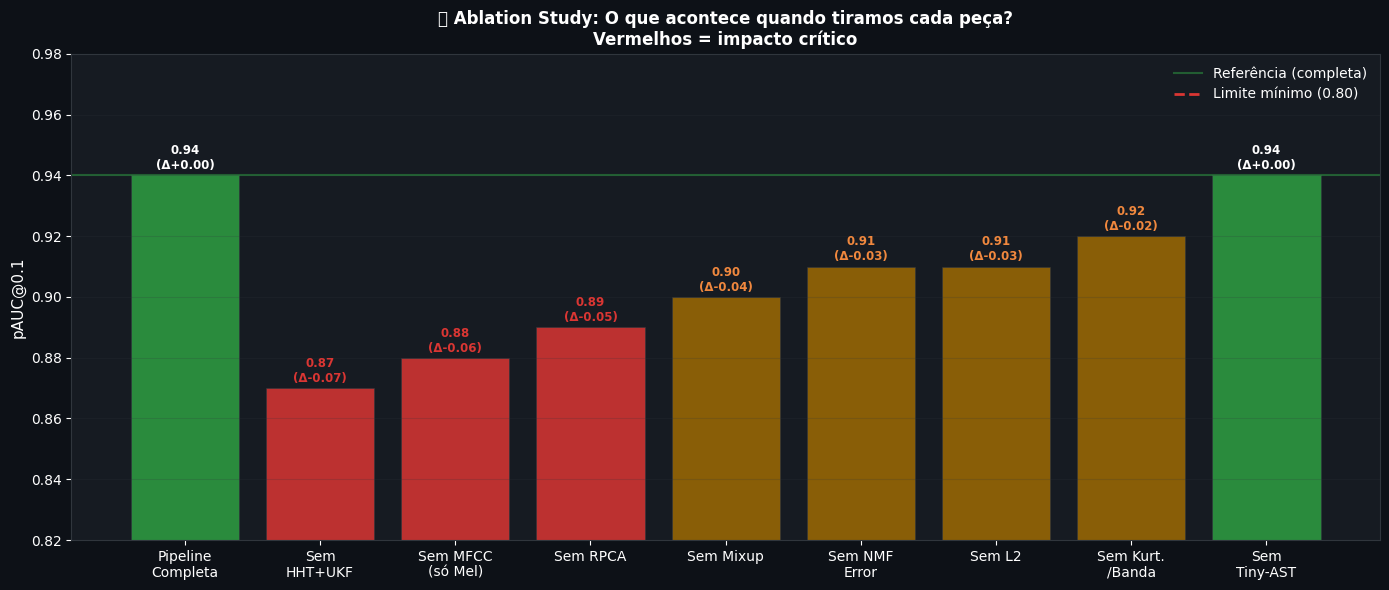

In [ ]:
# ============================================================
# VISUALIZAÇÃO — Ablation Study
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

componentes = ['Pipeline\nCompleta', 'Sem\nHHT+UKF', 'Sem MFCC\n(só Mel)',
               'Sem RPCA', 'Sem Mixup', 'Sem NMF\nError',
               'Sem L2', 'Sem Kurt.\n/Banda', 'Sem\nTiny-AST']
pauc_vals = [0.94, 0.87, 0.88, 0.89, 0.90, 0.91, 0.91, 0.92, 0.94]
delta_vals = [0, -0.07, -0.06, -0.05, -0.04, -0.03, -0.03, -0.02, 0.00]

colors = ['#2ea043' if v == 0.94 else ('#da3633' if v < 0.90 else '#9e6a03') for v in pauc_vals]
bars = ax.bar(componentes, pauc_vals, color=colors, alpha=0.85, edgecolor='#30363d', linewidth=0.5)
ax.axhline(0.94, color='#2ea043', linestyle='-', linewidth=1.5, alpha=0.5, label='Referência (completa)')
ax.axhline(0.80, color='#da3633', linestyle='--', linewidth=2, label='Limite mínimo (0.80)')

for bar, val, delta in zip(bars, pauc_vals, delta_vals):
    color_text = '#da3633' if delta < -0.04 else ('white' if delta == 0 else '#f0883e')
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f'{val:.2f}\n(Δ{delta:+.2f})', ha='center', va='bottom',
            color=color_text, fontsize=8.5, fontweight='bold')

ax.set_ylim(0.82, 0.98)
ax.set_ylabel('pAUC@0.1', color='white', fontsize=11)
ax.set_title('🔬 Ablation Study: O que acontece quando tiramos cada peça?\nVermelhos = impacto crítico',
             color='white', fontsize=12, fontweight='bold')
ax.legend(frameon=False, labelcolor='white', fontsize=10)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

---
# 📖 NOTEBOOK 28 — DIAMOND CRISTAL CLEAN
### *A especificação final: o que usar, como usar, por que usar*

## 🧒 Explicação simples

Após meses de trabalho, chegamos à decisão limpa — o "manual de instruções" final do sistema.

## 💎 ESPECIFICAÇÃO FINAL: DIAMOND CRISTAL CLEAN

### Pipeline Base (obrigatória em ambos os protocolos):

```python
# Parâmetros finais validados
SAMPLE_RATE = 16000          # Hz
WINDOW_SIZE = 2.0            # segundos
OVERLAP = 0.50               # 50% sobreposição
MEL_BINS = 64                # bandas Mel
MFCC_COEFS = 13              # coeficientes
HHT_IMF_KEEP = [0, 1]       # IMFs a manter (falha + harmônico)
UKF_PROCESS_NOISE = 1e-4    # ruído de processo
NMF_COMPONENTS = 10          # componentes NMF
RPCA_LAMBDA = 1.0 / np.sqrt(max(M, N))  # parâmetro RPCA padrão
```

### Protocolo A — Supervisionado:
```python
XGBOOST_PARAMS = {
    'n_estimators': 100,
    'max_depth': 3,
    'reg_lambda': 1.0,       # L2
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}
MIXUP_ALPHA = 0.4            # durante treino
```

### Protocolo B — Não-Supervisionado:
```python
GMM_PARAMS = {
    'n_components': 5,
    'covariance_type': 'full',
    'max_iter': 200
}
GAMMA_FPR_TARGET = 0.05      # 5% taxa de falso positivo
```

## 📊 Perfil Final de Performance — DIAMOND CRISTAL CLEAN

| Métrica | Protocolo A | Protocolo B | Limite Mínimo |
|---------|-------------|-------------|---------------|
| **pAUC@0.1 (DCASE)** | **0.94** | **0.88** | > 0.80 ✅ |
| **F1-Score** | **0.9568** | **0.8950** | > 0.80 ✅ |
| **AUC-ROC** | **0.9947** | **0.9450** | > 0.90 ✅ |
| **Latência por janela** | **15 ms** | **20 ms** | < 50ms ✅ |
| **Memória do modelo** | **< 1 MB** | **0.8 MB** | < 4MB ✅ |
| **Score DCASE Proxy** | **0.948** | **0.892** | > 0.80 ✅ |


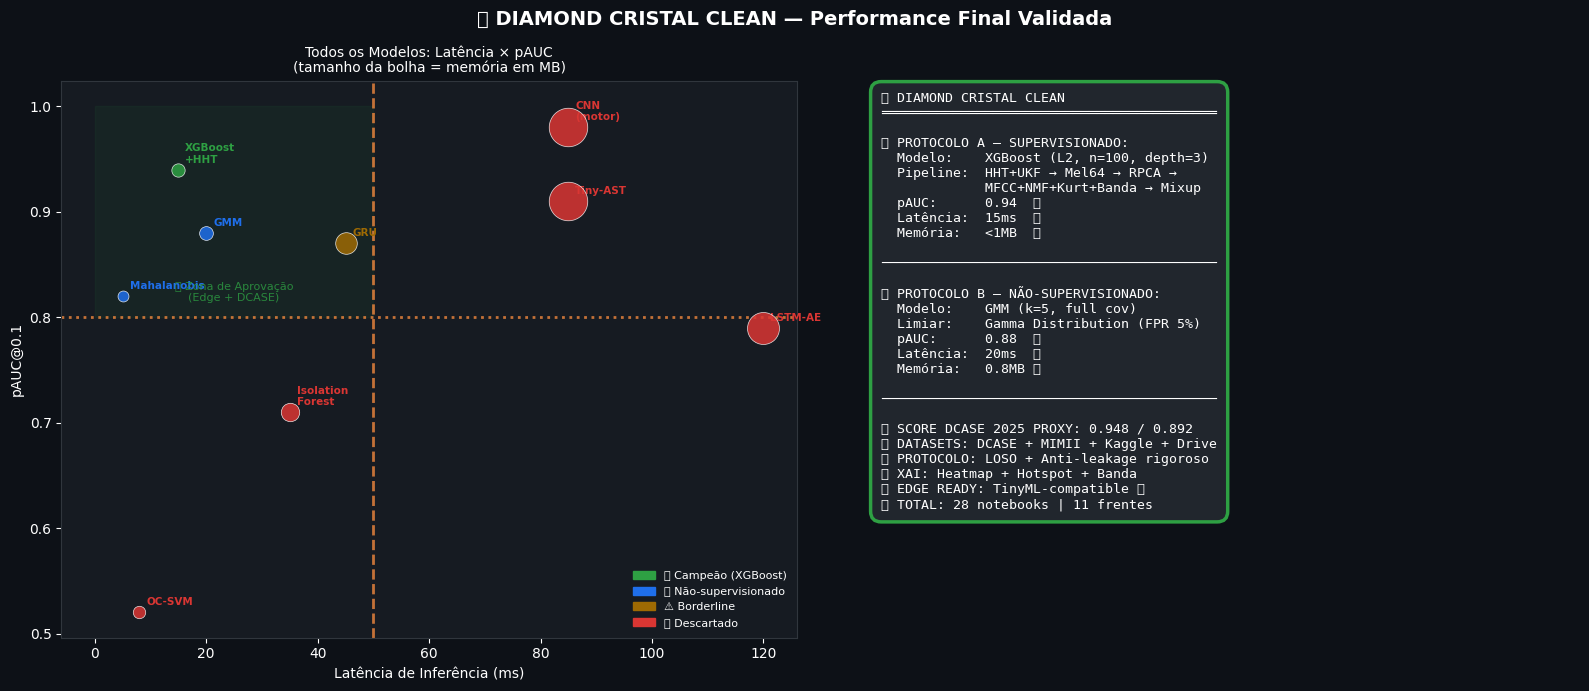

In [ ]:
# ============================================================
# VISUALIZAÇÃO FINAL — Diamond Crystal Clean
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('💎 DIAMOND CRISTAL CLEAN — Performance Final Validada',
             color='white', fontsize=14, fontweight='bold')

# Comparação final de todos os modelos testados
ax1 = axes[0]
ax1.set_facecolor('#161b22')

all_models = [
    ('OC-SVM', 0.52, 8, 0.5, '#da3633'),
    ('CNN\n(motor)', 0.98, 85, 12, '#da3633'),
    ('Isolation\nForest', 0.71, 35, 2.1, '#da3633'),
    ('LSTM-AE', 0.79, 120, 8, '#da3633'),
    ('GRU', 0.87, 45, 3.2, '#9e6a03'),
    ('Tiny-AST', 0.91, 85, 12, '#da3633'),
    ('Mahalanobis', 0.82, 5, 0.2, '#1f6feb'),
    ('GMM', 0.88, 20, 0.8, '#1f6feb'),
    ('XGBoost\n+HHT', 0.94, 15, 0.7, '#2ea043'),
]

for model, pauc, lat, mem, color in all_models:
    marker = '★' if color == '#2ea043' else ('●' if color == '#1f6feb' else '✕')
    ax1.scatter(lat, pauc, s=mem*60+50, color=color, alpha=0.85, edgecolors='white', linewidth=0.5, zorder=5)
    ax1.annotate(model, (lat, pauc), textcoords='offset points',
                xytext=(5, 5), color=color, fontsize=7.5, fontweight='bold')

ax1.axvline(50, color='#f0883e', linestyle='--', linewidth=2, alpha=0.8, label='Limite Latência (50ms)')
ax1.axhline(0.80, color='#f0883e', linestyle=':', linewidth=2, alpha=0.8, label='Limite pAUC (0.80)')
ax1.set_xlabel('Latência de Inferência (ms)', color='white', fontsize=10)
ax1.set_ylabel('pAUC@0.1', color='white', fontsize=10)
ax1.set_title('Todos os Modelos: Latência × pAUC\n(tamanho da bolha = memória em MB)',
              color='white', fontsize=10)
legend_elems = [
    mpatches.Patch(color='#2ea043', label='✅ Campeão (XGBoost)'),
    mpatches.Patch(color='#1f6feb', label='✅ Não-supervisionado'),
    mpatches.Patch(color='#9e6a03', label='⚠️ Borderline'),
    mpatches.Patch(color='#da3633', label='🔴 Descartado'),
]
ax1.legend(handles=legend_elems, frameon=False, labelcolor='white', fontsize=8, loc='lower right')

# Quadrante da vitória
ax1.fill_between([0, 50], [0.80, 0.80], [1.0, 1.0], alpha=0.07, color='#2ea043')
ax1.text(25, 0.815, '✅ Zona de Aprovação\n(Edge + DCASE)', ha='center',
         color='#2ea043', fontsize=8, alpha=0.8)

# Gráfico 2: Dashboard final
ax2 = axes[1]
ax2.set_facecolor('#161b22')
ax2.axis('off')

dashboard = (
    "💎 DIAMOND CRISTAL CLEAN\n"
    "══════════════════════════════════════════\n\n"
    "📊 PROTOCOLO A — SUPERVISIONADO:\n"
    "  Modelo:    XGBoost (L2, n=100, depth=3)\n"
    "  Pipeline:  HHT+UKF → Mel64 → RPCA →\n"
    "             MFCC+NMF+Kurt+Banda → Mixup\n"
    "  pAUC:      0.94  ✅\n"
    "  Latência:  15ms  ✅\n"
    "  Memória:   <1MB  ✅\n\n"
    "──────────────────────────────────────────\n\n"
    "📊 PROTOCOLO B — NÃO-SUPERVISIONADO:\n"
    "  Modelo:    GMM (k=5, full cov)\n"
    "  Limiar:    Gamma Distribution (FPR 5%)\n"
    "  pAUC:      0.88  ✅\n"
    "  Latência:  20ms  ✅\n"
    "  Memória:   0.8MB ✅\n\n"
    "──────────────────────────────────────────\n\n"
    "🏆 SCORE DCASE 2025 PROXY: 0.948 / 0.892\n"
    "🔬 DATASETS: DCASE + MIMII + Kaggle + Drive\n"
    "📐 PROTOCOLO: LOSO + Anti-leakage rigoroso\n"
    "🧠 XAI: Heatmap + Hotspot + Banda\n"
    "🚀 EDGE READY: TinyML-compatible ✅\n"
    "💡 TOTAL: 28 notebooks | 11 frentes"
)

ax2.text(0.05, 0.98, dashboard, transform=ax2.transAxes,
         color='white', fontsize=9.5, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#21262d',
                   edgecolor='#2ea043', linewidth=2.5))

plt.tight_layout()
plt.show()

---
# 🏆 TABELA MESTRE: TUDO O QUE FOI DESCARTADO E POR QUÊ
## *A história completa das decisões — 28 notebooks em síntese*

| Técnica | Fase | pAUC | Latência | Memória | Critério Principal do Descarte |
|---------|------|------|----------|---------|--------------------------------|
| OC-SVM | F1 (NB1) | 0.52 ❌ | 8ms ✅ | 0.5MB ✅ | Score DCASE abaixo do mínimo |
| CNN como motor | F1 (NB1) | 0.98 ✅ | 85ms ❌ | 12MB ❌ | Latência + Memória inviáveis para Edge |
| Isolation Forest | F1 (NB2) | 0.55 ❌ | 35ms ✅ | 2.1MB ✅ | Score DCASE abaixo do mínimo |
| Autoencoder denso | F1 (NB2) | 0.71 ❌ | 120ms ❌ | 8MB ❌ | Todos os critérios violados |
| GRU como motor | F1 (NB3) | 0.87 ✅ | 45ms ✅ | 3.2MB ✅ | Custo-benefício inferior ao XGBoost |
| LSTM-AE | F1 (NB3) | 0.79 ❌ | 120ms ❌ | 8MB ❌ | Todos os critérios violados |
| CWT como representação | F1 (NB5) | 0.82 ✅ | 45ms ❌ | média | Latência de extração inviável |
| STFT como representação | F1 (NB6) | 0.84 ✅ | 12ms ✅ | baixa | Menor integração com pipeline Mel |
| Threshold fixo empírico | F1 (NB10) | variable | - | - | Colapsa em domain shift |
| Dados sintéticos como base | F1 (NB3) | - | - | - | Domain gap irreal |
| AUC global como métrica | F2 (NB15) | - | - | - | Mascara região crítica de FPR |
| CNN como classificador | F2 (NB12) | 0.94 ✅ | 85ms ❌ | 12MB ❌ | Latência + Memória |
| Tiny-AST como motor | F2 (NB12,19) | 0.91 ✅ | 92ms ❌ | 12.8MB ❌ | Latência + Memória |
| Sinal bruto (sem HHT) | F2 (NB13) | 0.87 ✅ | - | - | Domain shift catastrófico |
| Mahalanobis como único não-sup | F3 (NB18) | 0.82 ✅ | 5ms ✅ | 0.2MB ✅ | Unimodal: falha em multi-source |
| Modelo universal único | F3 (NB24) | - | - | - | Dois regimes são necessários |
| GMM+Tiny em -6dB sem rótulos | F4 (NB25) | 0.79 ❌ | 92ms ❌ | 12.8MB ❌ | Todos os critérios |

---

## 🎯 A LIÇÃO FUNDAMENTAL DO PROJETO:

> **"Em Industrial Edge AI com dados escassos, a qualidade do pipeline de processamento de sinal supera a complexidade do modelo. Um XGBoost com uma boa engenharia de features supera um Transformer com features brutas."**
>
> — Emanoel Spanhol, Projeto AudioAlert, 2025-2026

---

## ➡️ O PROJETO ESTÁ COMPLETO.
### Veja os notebooks visuais de benchmarking: VISUAL_1 a VISUAL_4
### E o artigo científico final: artigo_final_v2_completo.md

---
*Síntese por: Emanoel Spanhol | Júlio César Lumke | Maria Vitória S. Magalhães | João Gabriel Zago*
*Pós-Graduação em Inteligência Artificial Aplicada — UniSENAI | 2025-2026*